In [1]:
import numpy as np
from empiricaldist import Pmf
from scipy.stats import binom

## 4.2 The Binomial Distribution

In [3]:
def make_binomial(n, p):
    """Make a binomial Pmf."""
    ks = np.arange(n+1)
    ps = binom.pmf(ks, n, p)
    return Pmf(ps, ks)

def prob_ge(pmf, threshold):
    """Probability of quantities greater than threshold."""
    ge = (pmf.qs >= threshold)
    total = pmf[ge].sum()
    return total

pmf_k = make_binomial(n=250, p=0.5)
pmf_k.prob_ge(140) + pmf_k.prob_le(110)

0.06642115124004336

## 4.3 Bayesian Estimation

<Axes: >

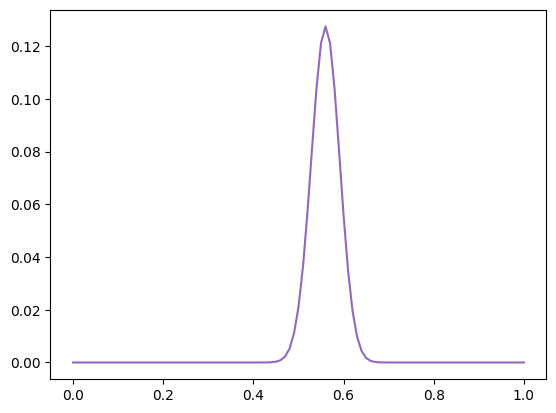

In [4]:
hypos = np.linspace(0, 1, 101)
prior = Pmf(1, hypos)

likelihood_heads = hypos
likelihood_tails = 1 - hypos
likelihood = {
    'H': likelihood_heads,
    'T': likelihood_tails
}

dataset = 'H' * 140 + 'T' * 110
def update_euro(pmf, dataset):
    """Update pmf with a given sequence of H and T."""
    for data in dataset:
        pmf *= likelihood[data]

    pmf.normalize()

posterior = prior.copy()
update_euro(posterior, dataset)
posterior.plot(label='140 heads out of 250', color='C4')

In [5]:
posterior.max_prob()

0.56

## 4.4 Triangle Prior

<Axes: >

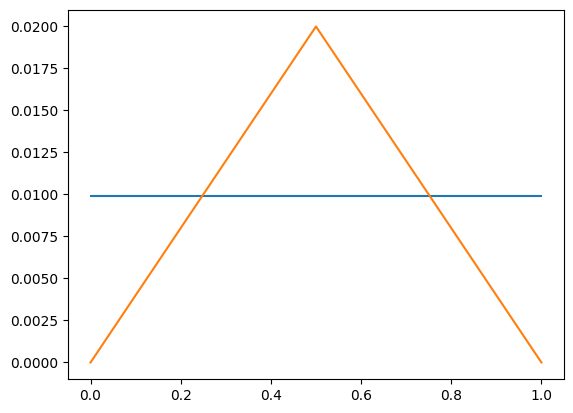

In [6]:
uniform = Pmf(1, hypos, name='uniform')
uniform.normalize()

ramp_up = np.arange(50)
ramp_down = np.arange(50, -1, -1)
a = np.append(ramp_up, ramp_down)
triangle = Pmf(a, hypos, name='triangle')
triangle.normalize()

uniform.plot()
triangle.plot()

<Axes: >

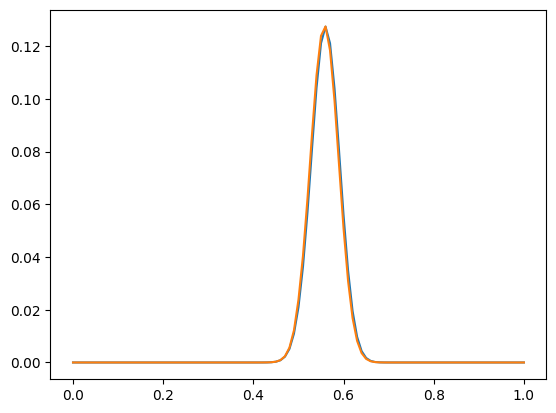

In [7]:
update_euro(uniform, dataset)
update_euro(triangle, dataset)
uniform.plot()
triangle.plot()

## 4.5 The Binomial Likelihood Function

In [10]:
def update_binomial(pmf, data):
    """Update pmf using the binomial distribution."""
    k, n = data
    xs = pmf.qs
    likelihood = binom.pmf(k, n, xs)
    pmf *= likelihood
    pmf.normalize()


uniform2 = Pmf(1, hypos, name='uniform2')
data = 140, 250
update_binomial(uniform2, data)
np.allclose(uniform, uniform2)

True